# Film Tourism in Greece: Survey Analysis

**Context.** Re-analysis of the questionnaire collected for the University of West Attica course
*Case Studies in Tourism* (Dept. of Tourism Management, 2022-23; supervisor: Prof. S. Koufadakis; written with a classmate).
The original paper reported descriptive percentages only. This notebook rebuilds the analysis reproducibly in Python:
cleaning with a documented log, validation against the published figures, confidence intervals, and a small set of
pre-specified hypothesis tests with multiple-comparison correction.

**Question.** Is there demand for film-location tourism in Greece, and do attitudes differ between students and other respondents?

**Data.** 60 anonymous responses to a 21-question online questionnaire (Google Forms, Dec 2022): film-watching habits,
festival attendance, motivation to visit film locations (1-10 scale), willingness to travel, perception of state management,
perceived COVID-19 impact, and demographics. Sample: 39 students, 18 art & culture enthusiasts, 3 professionals (convenience sample).

**Pipeline:** load -> clean -> validate against the original paper -> describe (with 95% CIs) -> test -> summarise.

In [1]:
import re, unicodedata, warnings, json
from datetime import datetime
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings("ignore")

ROOT = Path.cwd()
RAW  = ROOT / "data" / "raw" / "survey_responses_raw.xlsx"
FIG  = ROOT / "figures";            FIG.mkdir(exist_ok=True)
PROC = ROOT / "data" / "processed"; PROC.mkdir(parents=True, exist_ok=True)
RES  = ROOT / "results";            RES.mkdir(exist_ok=True)

# Reference palette (light surface). Categorical slots 1-3, fixed order.
SURFACE, INK, INK2, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#b9b8b0"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": INK2, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "savefig.dpi": 200, "figure.dpi": 110,
})

## 1. Load and standardise the raw data

The raw workbook has one sheet per respondent group. Column positions are used (the original headers are in Greek);
the English names below follow the questionnaire order.

In [2]:
GROUPS = ["Students", "Professionals", "Art & culture enthusiasts"]   # sheet order in the workbook
COLS = ["respondent", "films_per_year", "greek_films_per_year", "favourite_genre", "attended_festival",
        "festival_names", "motivation_visit_location", "visited_film_set", "would_travel_to_film_set",
        "set_inside_or_outside_greece", "knows_film_locations", "travelled_to_film_locations",
        "many_visitable_sets", "where_most_sets", "how_many_sets", "prospects_for_film_tourism",
        "state_management", "improvement_suggestion", "covid_affected", "covid_impact_score", "age", "gender"]

xl = pd.ExcelFile(RAW)
frames = []
for sheet, grp in zip(xl.sheet_names, GROUPS):
    d = xl.parse(sheet).dropna(how="all")
    assert d.shape[1] == len(COLS), (sheet, d.shape)
    d.columns = COLS
    d = d[d["respondent"].astype(str).str.contains("#")].copy()
    d.insert(1, "group", grp)
    frames.append(d)
raw = pd.concat(frames, ignore_index=True)
print(raw.shape, raw["group"].value_counts().to_dict())

(60, 23) {'Students': 39, 'Art & culture enthusiasts': 18, 'Professionals': 3}


## 2. Cleaning (with a log)

Issues found in the raw file, and how each was handled:

1. **Header/data mismatch.** In the workbook the headers of columns 13 and 14 ("how many sets" / "where are most sets") are swapped relative
   to the data. Content was checked: column 13 holds place names, column 14 holds count ranges. Variables are named by content.
2. **Excel auto-converted ranges to dates.** Entries typed as `11 - 20` became `1 Nov 2020`. Restored (month-year -> `11-20`).
3. **Inconsistent labels** for the same category (`21 έως 30` / `21 - 30`, `0 έως 5` / `0 - 5`, `Ναι`/`ναι`...). Harmonised.
4. **Free-text numbers** in `age` (`"21 ετών"`). Parsed to integers.
5. **One truncated answer** (`"11 εώς"`) in the count-range column. Interpreted as `11-20` (the only range starting at 11).

In [3]:
log = {}

def norm(x):
    s = unicodedata.normalize("NFD", str(x).strip().lower())
    return "".join(ch for ch in s if unicodedata.category(ch) != "Mn").replace("\u03c2", "\u03c3")

def yes_no(x):
    n = norm(x)
    if n.startswith("\u03bd\u03b1\u03b9"):                 return "Yes"       # ναι
    if n.startswith("\u03bf\u03c7\u03b9"):                 return "No"        # οχι
    if n.startswith("\u03b4\u03b5\u03bd \u03b3\u03bd\u03c9\u03c1\u03b9\u03b6"): return "Unsure"   # δεν γνωριζω
    return np.nan

def range_label(x, truncated_fix=None):
    # Excel-damaged dates first: '11 - 20' -> datetime(2020, 11, 1)
    if isinstance(x, (datetime, pd.Timestamp)):
        log["excel_date_cells_repaired"] = log.get("excel_date_cells_repaired", 0) + 1
        return f"{x.month}-{x.year % 100}"
    n = norm(x); nums = re.findall(r"\d+", n)
    if "\u03c0\u03b1\u03c1\u03b1\u03c0\u03b1\u03bd\u03c9" in n:                        # παραπανω
        return f"{nums[-1]}+"
    if len(nums) >= 2: return f"{nums[0]}-{nums[1]}"
    if len(nums) == 1 and truncated_fix and nums[0] in truncated_fix:
        log["truncated_answers_interpreted"] = log.get("truncated_answers_interpreted", 0) + 1
        return truncated_fix[nums[0]]
    return np.nan

GENRE = {"\u03ba\u03bf\u03b9\u03bd\u03c9\u03bd\u03b9\u03ba\u03b5\u03c3 - \u03b4\u03c1\u03b1\u03bc\u03b1\u03c4\u03b9\u03ba\u03b5\u03c3": "Social / drama",
         "\u03b1\u03c3\u03c4\u03c5\u03bd\u03bf\u03bc\u03b9\u03ba\u03b5\u03c3": "Crime", "\u03c1\u03bf\u03bc\u03b1\u03bd\u03c4\u03b9\u03ba\u03b5\u03c3": "Romance"}
PLACE = {"\u03b5\u03bd\u03c4\u03bf\u03c3 \u03b5\u03bb\u03bb\u03b1\u03b4\u03b1\u03c3.": "Inside Greece", "\u03b5\u03ba\u03c4\u03bf\u03c3 \u03b5\u03bb\u03bb\u03b1\u03b4\u03b1\u03c3.": "Outside Greece"}
MGMT  = {"\u03bf\u03c1\u03b8\u03bf\u03c3": "Appropriate", "\u03bb\u03b1\u03bd\u03b8\u03b1\u03c3\u03bc\u03b5\u03bd\u03bf\u03c3": "Inappropriate"}
SEX   = {"\u03b3\u03c5\u03bd\u03b1\u03b9\u03ba\u03b1": "Female", "\u03b1\u03bd\u03b4\u03c1\u03b1\u03c3": "Male", "\u03b1\u03bb\u03bb\u03bf": "Other"}

def lookup(x, table):
    n = norm(x)
    if n.startswith("\u03b4\u03b5\u03bd \u03b3\u03bd\u03c9\u03c1\u03b9\u03b6"): return "Unsure"
    return table.get(n, np.nan)

df = pd.DataFrame({
    "respondent": raw["respondent"], "group": raw["group"],
    "films_per_year":       raw["films_per_year"].map(range_label),
    "greek_films_per_year": raw["greek_films_per_year"].map(range_label),
    "favourite_genre":      raw["favourite_genre"].map(lambda v: lookup(v, GENRE)),
    "attended_festival":    raw["attended_festival"].map(yes_no),
    "motivation_visit_location": pd.to_numeric(raw["motivation_visit_location"], errors="coerce"),
    "visited_film_set":     raw["visited_film_set"].map(yes_no),
    "would_travel_to_film_set": raw["would_travel_to_film_set"].map(yes_no),
    "set_inside_or_outside_greece": raw["set_inside_or_outside_greece"].map(lambda v: lookup(v, PLACE)),
    "knows_film_locations": raw["knows_film_locations"].map(yes_no),
    "travelled_to_film_locations": raw["travelled_to_film_locations"].map(yes_no),
    "many_visitable_sets":  raw["many_visitable_sets"].map(yes_no),
    "how_many_sets":        raw["how_many_sets"].map(lambda v: range_label(v, truncated_fix={"11": "11-20"})),
    "where_most_sets":      raw["where_most_sets"].astype(str),
    "prospects_for_film_tourism": raw["prospects_for_film_tourism"].map(yes_no),
    "state_management":     raw["state_management"].map(lambda v: lookup(v, MGMT)),
    "improvement_suggestion": raw["improvement_suggestion"].astype(str),
    "covid_affected":       raw["covid_affected"].map(yes_no),
    "covid_impact_score":   pd.to_numeric(raw["covid_impact_score"], errors="coerce"),
    "age":                  raw["age"].astype(str).str.extract(r"(\d+)")[0].astype(float),
    "gender":               raw["gender"].map(lambda v: SEX.get(norm(v), np.nan)),
})
log["age_cells_with_text_parsed"] = int(raw["age"].map(lambda v: isinstance(v, str) and not v.strip().isdigit()).sum())

# --- integrity checks -------------------------------------------------------------------------
assert len(df) == 60 and df["respondent"].is_unique
assert df["motivation_visit_location"].between(1, 10).all() and df["covid_impact_score"].between(1, 10).all()
assert df["how_many_sets"].isin(["0-10", "11-20", "20+"]).all(), df["how_many_sets"].value_counts(dropna=False)
assert df["films_per_year"].isin(["1-10", "11-20", "21-30", "30+"]).all(), df["films_per_year"].value_counts(dropna=False)
yn_cols = ["attended_festival","visited_film_set","would_travel_to_film_set","knows_film_locations",
           "travelled_to_film_locations","many_visitable_sets","prospects_for_film_tourism","covid_affected"]
assert df[yn_cols].notna().all().all()
assert df["gender"].notna().all() and df["state_management"].notna().all()

df.to_csv(PROC / "survey_clean.csv", index=False, encoding="utf-8-sig")
print("Cleaning log:", json.dumps(log, indent=2))
print("Missing values per column:"); print(df.isna().sum()[df.isna().sum() > 0].to_string() or "none")

Cleaning log: {
  "truncated_answers_interpreted": 1,
  "excel_date_cells_repaired": 2,
  "age_cells_with_text_parsed": 2
}
Missing values per column:
Series([], )


## 3. Validation against the original paper

Before analysing anything new, the cleaned data is checked against the counts reported in the original written paper.
If the pipeline is right, the numbers should match.

In [4]:
paper = [  # (label, value reported in the paper, value in the cleaned data)
    ("Respondents",                               60, len(df)),
    ("Students",                                  39, (df.group == "Students").sum()),
    ("Art & culture enthusiasts",                 18, (df.group == "Art & culture enthusiasts").sum()),
    ("Professionals",                              3, (df.group == "Professionals").sum()),
    ("Women",                                     39, (df.gender == "Female").sum()),
    ("Men",                                       20, (df.gender == "Male").sum()),
    ("Watch 0-5 Greek films/year",                44, (df.greek_films_per_year == "0-5").sum()),
    ("Watch 6-10 Greek films/year",               12, (df.greek_films_per_year == "6-10").sum()),
    ("Prefer social/drama films",                 40, (df.favourite_genre == "Social / drama").sum()),
    ("Attended a film festival",                  11, (df.attended_festival == "Yes").sum()),
    ("Visited a film set",                        18, (df.visited_film_set == "Yes").sum()),
    ("Would travel to a film set: Yes",           35, (df.would_travel_to_film_set == "Yes").sum()),
    ("Would travel to a film set: No",            11, (df.would_travel_to_film_set == "No").sum()),
    ("Know film locations",                       58, (df.knows_film_locations == "Yes").sum()),
    ("Travelled to film locations",               38, (df.travelled_to_film_locations == "Yes").sum()),
    ("Many visitable sets exist: Yes",            33, (df.many_visitable_sets == "Yes").sum()),
    ("Estimate 0-10 sets",                        37, (df.how_many_sets == "0-10").sum()),
    ("Estimate 11-20 sets",                       11, (df.how_many_sets == "11-20").sum()),
    ("Estimate 20+ sets",                         12, (df.how_many_sets == "20+").sum()),
    ("State management 'inappropriate'",          36, (df.state_management == "Inappropriate").sum()),
    ("COVID-19 affected film tourism: Yes",       52, (df.covid_affected == "Yes").sum()),
    ("Aged 21",                                   20, (df.age == 21).sum()),
    ("Watch 11-20 films/year",                    21, (df.films_per_year == "11-20").sum()),
    ("Watch 1-10 films/year",                     15, (df.films_per_year == "1-10").sum()),
]
val = pd.DataFrame(paper, columns=["metric", "paper", "dataset"])
val["match"] = np.where(val.paper == val.dataset, "yes", "NO")
val.to_csv(RES / "validation_vs_paper.csv", index=False)
print(f"{(val.match == 'yes').sum()} of {len(val)} figures reproduced exactly")
val[val.match != "yes"]

21 of 24 figures reproduced exactly


,metric,paper,dataset,match
21,Aged 21,20,21,NO
22,Watch 11-20 films/year,21,22,NO
23,Watch 1-10 films/year,15,14,NO


**Reconciliation note.** 21 of 24 published figures reproduce exactly. The three that differ are each off by **one respondent**:
- *Aged 21*: the paper reports 20, the dataset gives 21. One respondent typed their age as text ("21 ετών"), which a manual count would have skipped; the parser recovers it.
- *Films per year*: the dataset has 22 in "11-20" and 14 in "1-10" versus 21 and 15 in the paper, most likely a late edit to the sheet or a transcription slip.

The dataset values are used throughout. No conclusion below depends on these two variables.

## 4. Descriptive results with 95% confidence intervals

With n = 60, a single percentage carries a margin of roughly +/-12 points, so every headline proportion is reported with a Wilson 95% interval.

In [5]:
def wilson(k, n, z=1.96):
    p = k / n; d = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / d
    h = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return p, max(0, c - h), min(1, c + h)

indicators = {
    "Know places where films were shot":               df.knows_film_locations == "Yes",
    "Believe film tourism has prospects in Greece":    df.prospects_for_film_tourism == "Yes",
    "Believe COVID-19 affected film tourism":          df.covid_affected == "Yes",
    "Would travel to visit a film set":                df.would_travel_to_film_set == "Yes",
    "Rate state management of film sets as inappropriate": df.state_management == "Inappropriate",
    "Have visited a film set":                         df.visited_film_set == "Yes",
    "Have attended a film festival":                   df.attended_festival == "Yes",
}
rows = []
for label, s in indicators.items():
    p, lo, hi = wilson(int(s.sum()), len(s))
    rows.append({"indicator": label, "n_yes": int(s.sum()), "n": len(s), "pct": p, "ci_low": lo, "ci_high": hi})
key = pd.DataFrame(rows).sort_values("pct")
key.to_csv(RES / "key_indicators.csv", index=False)
key.assign(pct=lambda d: (d.pct*100).round(1), ci_low=lambda d: (d.ci_low*100).round(1), ci_high=lambda d: (d.ci_high*100).round(1)).iloc[::-1].reset_index(drop=True)

,indicator,n_yes,n,pct,ci_low,ci_high
0,Know places where films were shot,58,60,96.7,88.6,99.1
1,Believe COVID-19 affected film tourism,52,60,86.7,75.8,93.1
2,Believe film tourism has prospects in Greece,45,60,75.0,62.8,84.2
3,Rate state management of film sets as inapprop...,36,60,60.0,47.4,71.4
4,Would travel to visit a film set,35,60,58.3,45.7,69.9
5,Have visited a film set,18,60,30.0,19.9,42.5
6,Have attended a film festival,11,60,18.3,10.6,29.9


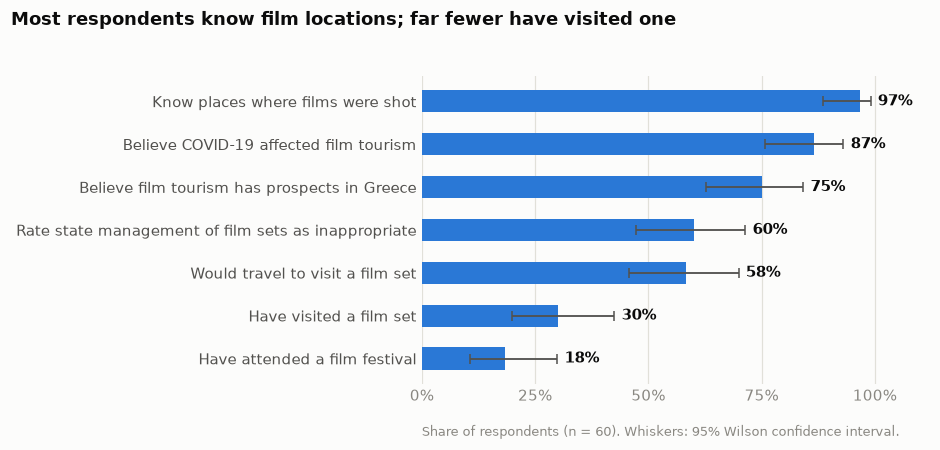

In [6]:
fig, ax = plt.subplots(figsize=(8.6, 4.2))
y = np.arange(len(key))
ax.barh(y, key.pct * 100, height=0.52, color=BLUE, zorder=2)
ax.errorbar(key.pct * 100, y, xerr=[(key.pct - key.ci_low) * 100, (key.ci_high - key.pct) * 100],
            fmt="none", ecolor=INK2, elinewidth=1.2, capsize=3, zorder=3)
for yi, (p, hi) in enumerate(zip(key.pct, key.ci_high)):
    ax.text(hi * 100 + 1.6, yi, f"{p*100:.0f}%", va="center", fontsize=10, color=INK, fontweight="bold")
ax.set_yticks(y, key.indicator); ax.set_xlim(0, 112); ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels([f"{t}%" for t in [0, 25, 50, 75, 100]]); ax.xaxis.grid(True, color=GRID, lw=0.8, zorder=0)
ax.tick_params(axis="both", length=0); ax.spines["left"].set_visible(False); ax.spines["bottom"].set_visible(False)
fig.suptitle("Most respondents know film locations; far fewer have visited one", x=0.012, ha="left", fontsize=12, fontweight="bold")
ax.text(0, -0.17, "Share of respondents (n = 60). Whiskers: 95% Wilson confidence interval.", transform=ax.transAxes, fontsize=8.5, color=MUTED)
fig.tight_layout(rect=(0, 0, 1, 0.95)); fig.savefig(FIG / "fig1_key_indicators.png"); plt.show()

## 5. Willingness to travel and motivation, by respondent group

Because only 3 professionals responded, comparisons use **students (n = 39)** versus **all other respondents (n = 21)**.

In [7]:
df["segment"] = np.where(df.group == "Students", "Students", "Others")
ct = pd.crosstab(df.segment, df.would_travel_to_film_set).reindex(columns=["Yes", "Unsure", "No"]).loc[["Students", "Others"]]
pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct.assign(n=ct.sum(axis=1))

would_travel_to_film_set,Yes,Unsure,No,n
segment,,,,
Students,27,7,5,39
Others,8,7,6,21


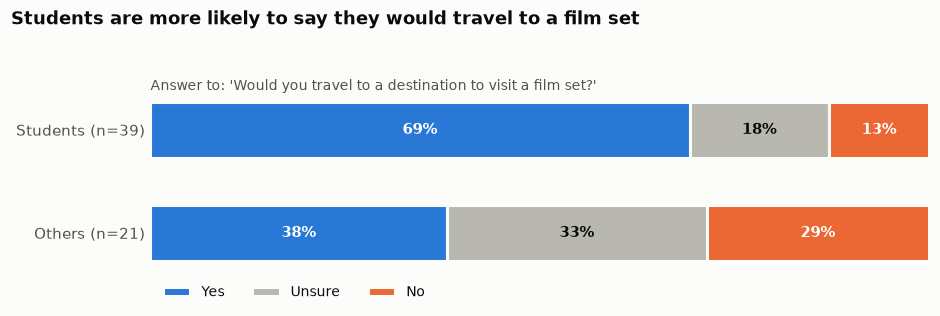

In [8]:
fig, ax = plt.subplots(figsize=(8.6, 2.9))
colors = {"Yes": BLUE, "Unsure": GREY, "No": ORANGE}; text_c = {"Yes": "white", "Unsure": INK, "No": "white"}
for yi, seg in enumerate(["Students", "Others"][::-1]):
    left = 0
    for cat in ["Yes", "Unsure", "No"]:
        w = pct.loc[seg, cat]
        ax.barh(yi, w, left=left, height=0.55, color=colors[cat], edgecolor=SURFACE, linewidth=2, label=cat if yi == 0 else None)
        if w >= 6: ax.text(left + w / 2, yi, f"{w:.0f}%", ha="center", va="center", color=text_c[cat], fontsize=10, fontweight="bold")
        left += w
ax.set_yticks([0, 1], [f"Others (n={ct.loc['Others'].sum()})", f"Students (n={ct.loc['Students'].sum()})"])
ax.set_xlim(0, 100); ax.set_xticks([]); ax.tick_params(length=0)
for s in ["left", "bottom"]: ax.spines[s].set_visible(False)
fig.suptitle("Students are more likely to say they would travel to a film set", x=0.012, ha="left", fontsize=12, fontweight="bold")
ax.text(0, 1.02, "Answer to: 'Would you travel to a destination to visit a film set?'", transform=ax.transAxes, fontsize=9, color=INK2)
ax.legend(ncol=3, frameon=False, loc="upper left", bbox_to_anchor=(0, -0.02), fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.93)); fig.savefig(FIG / "fig2_travel_by_segment.png"); plt.show()

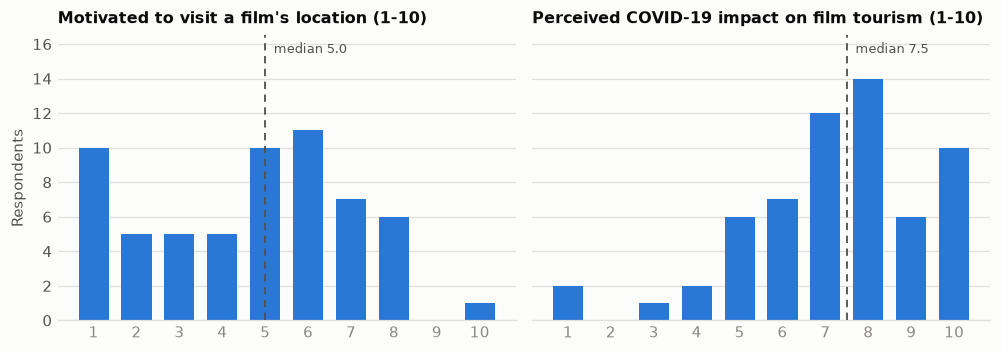

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.3), sharey=True)
for ax, col, title in zip(axes, ["motivation_visit_location", "covid_impact_score"],
                          ["Motivated to visit a film's location (1-10)", "Perceived COVID-19 impact on film tourism (1-10)"]):
    counts = df[col].value_counts().reindex(range(1, 11), fill_value=0)
    ax.bar(counts.index, counts.values, width=0.7, color=BLUE, zorder=2)
    ax.axvline(df[col].median(), color=INK2, lw=1.2, ls=(0, (4, 3)), zorder=3)
    ax.text(df[col].median() + 0.2, 15.3, f"median {df[col].median():.1f}", fontsize=8.5, color=INK2, va="bottom")
    ax.set_xticks(range(1, 11)); ax.set_title(title, fontsize=10.5, pad=8); ax.tick_params(length=0)
    ax.yaxis.grid(True, color=GRID, lw=0.8, zorder=0); ax.spines["left"].set_visible(False); ax.set_ylim(0, 16.5)
axes[0].set_ylabel("Respondents"); fig.tight_layout(); fig.savefig(FIG / "fig3_score_distributions.png"); plt.show()

## 6. Hypothesis tests

Seven comparisons were chosen **before** looking at results, motivated by the paper's research questions. Because there are seven,
p-values are adjusted with the **Holm** method. Tests are chosen for the data type: Fisher's exact test for yes/no outcomes (small cell counts),
Mann-Whitney U for the 1-10 scores (ordinal, non-normal), Spearman's rho for ordinal associations.
Effect sizes: odds ratio (with 95% CI), rank-biserial correlation, Spearman's rho.

In [10]:
def fisher(a_yes, a_n, b_yes, b_n):
    table = [[a_yes, a_n - a_yes], [b_yes, b_n - b_yes]]
    odds, p = stats.fisher_exact(table)
    t = np.array(table, float) + 0.5
    se = np.sqrt((1 / t).sum()); lo, hi = np.exp(np.log(t[0, 0] * t[1, 1] / (t[0, 1] * t[1, 0])) + np.array([-1.96, 1.96]) * se)
    return p, f"OR = {odds:.2f} (95% CI {lo:.2f}-{hi:.2f})"

def mwu(a, b):
    a, b = a.dropna(), b.dropna()
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    rbc = 2 * u / (len(a) * len(b)) - 1
    return p, f"rank-biserial r = {rbc:+.2f}; medians {a.median():.1f} vs {b.median():.1f}"

stu = df.segment == "Students"; yes_travel = df.would_travel_to_film_set == "Yes"
seen = df.visited_film_set == "Yes"; female = df.gender == "Female"; male = df.gender == "Male"
films_ord = df.films_per_year.map({"1-10": 1, "11-20": 2, "21-30": 3, "30+": 4})

tests = []
p, e = fisher(yes_travel[stu].sum(), stu.sum(), yes_travel[~stu].sum(), (~stu).sum())
tests.append(("T1", "Would travel to a film set (yes vs not yes): students vs others", "Fisher exact", p, e))
p, e = mwu(df.motivation_visit_location[stu], df.motivation_visit_location[~stu])
tests.append(("T2", "Motivation score (1-10): students vs others", "Mann-Whitney U", p, e))
p, e = mwu(df.motivation_visit_location[seen], df.motivation_visit_location[~seen])
tests.append(("T3", "Motivation score (1-10): has visited a film set vs not", "Mann-Whitney U", p, e))
p, e = fisher(yes_travel[seen].sum(), seen.sum(), yes_travel[~seen].sum(), (~seen).sum())
tests.append(("T4", "Would travel (yes vs not yes): has visited a film set vs not", "Fisher exact", p, e))
rho, p = stats.spearmanr(films_ord, df.motivation_visit_location)
tests.append(("T5", "Films watched per year (ordinal) vs motivation score", "Spearman", p, f"rho = {rho:+.2f}"))
p, e = mwu(df.motivation_visit_location[female], df.motivation_visit_location[male])
tests.append(("T6", "Motivation score (1-10): women vs men (1 'other' excluded)", "Mann-Whitney U", p, e))
bad = df.state_management == "Inappropriate"
p, e = fisher(bad[stu].sum(), stu.sum(), bad[~stu].sum(), (~stu).sum())
tests.append(("T7", "State management rated inappropriate: students vs others", "Fisher exact", p, e))

res = pd.DataFrame(tests, columns=["id", "comparison", "test", "p_raw", "effect"])
# Holm step-down adjustment
order = res.p_raw.argsort().values; m = len(res); adj = np.empty(m); running = 0
for rank, i in enumerate(order):
    running = max(running, (m - rank) * res.p_raw.iloc[i]); adj[i] = min(1, running)
res["p_holm"] = adj
res["significant_5pct"] = np.where(res.p_holm < 0.05, "yes", "no")
res.to_csv(RES / "hypothesis_tests.csv", index=False)
res.assign(p_raw=res.p_raw.round(3), p_holm=res.p_holm.round(3))

,id,comparison,test,p_raw,effect,p_holm,significant_5pct
0,T1,Would travel to a film set (yes vs not yes): s...,Fisher exact,0.028,OR = 3.66 (95% CI 1.18-10.37),0.193,no
1,T2,Motivation score (1-10): students vs others,Mann-Whitney U,0.521,rank-biserial r = +0.10; medians 5.0 vs 5.0,1.000,no
2,T3,Motivation score (1-10): has visited a film se...,Mann-Whitney U,0.234,rank-biserial r = +0.19; medians 5.5 vs 4.5,0.740,no
3,T4,Would travel (yes vs not yes): has visited a f...,Fisher exact,0.052,OR = 3.50 (95% CI 0.96-10.86),0.262,no
4,T5,Films watched per year (ordinal) vs motivation...,Spearman,0.028,rho = +0.28,0.193,no
5,T6,Motivation score (1-10): women vs men (1 'othe...,Mann-Whitney U,0.185,rank-biserial r = +0.21; medians 5.0 vs 4.0,0.740,no
6,T7,State management rated inappropriate: students...,Fisher exact,1.000,OR = 0.88 (95% CI 0.31-2.60),1.000,no


## 7. What do respondents suggest? (open-ended answers)

Keyword-based theme coding of the free-text improvement suggestions (accent-insensitive; a response can carry several themes).
This is a coarse screen, not a substitute for manual coding.

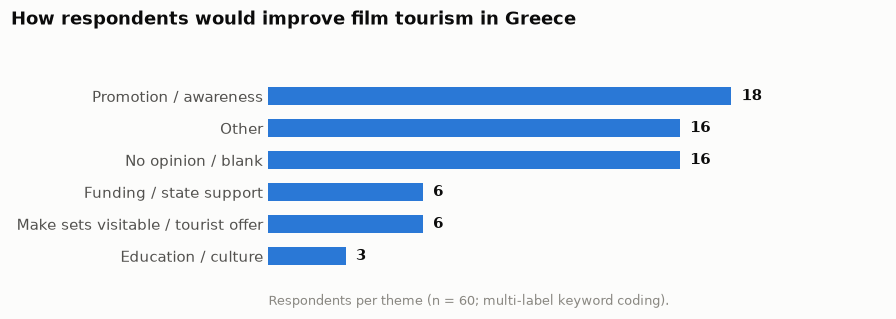

Promotion / awareness                  18
Other                                  16
No opinion / blank                     16
Funding / state support                 6
Make sets visitable / tourist offer     6
Education / culture                     3
dtype: int64

In [11]:
THEMES = {
    "Funding / state support": r"\u03c7\u03c1\u03b7\u03bc\u03b1\u03c4\u03bf\u03b4\u03bf\u03c4|\u03b5\u03c0\u03b9\u03b4\u03bf\u03c4|\u03ba\u03c1\u03b1\u03c4|\u03ba\u03bf\u03bd\u03b4\u03c5\u03bb|\u03c0\u03bf\u03bb\u03b9\u03c4\u03b9\u03ba",
    "Promotion / awareness":   r"\u03c0\u03c1\u03bf\u03c9\u03b8|\u03b4\u03b9\u03b1\u03c6\u03b7\u03bc|\u03b5\u03bd\u03b7\u03bc\u03b5\u03c1\u03c9\u03c3|\u03c0\u03c1\u03bf\u03b2\u03bf\u03bb|\u03b3\u03bd\u03c9\u03c3\u03c4|marketing",
    "Make sets visitable / tourist offer": r"\u03b5\u03c0\u03b9\u03c3\u03ba\u03b5\u03c8\u03b9\u03bc|\u03b5\u03c0\u03b9\u03c3\u03ba\u03b5\u03c0\u03c4|\u03bf\u03b4\u03b7\u03b3|\u03c0\u03b1\u03ba\u03b5\u03c4|\u03b4\u03b9\u03b1\u03b4\u03c1\u03bf\u03bc|\u03c4\u03bf\u03c5\u03c1\u03b9\u03c3\u03c4\u03b9\u03ba|\u03c5\u03c0\u03bf\u03b4\u03bf\u03bc",
    "Education / culture":     r"\u03b5\u03ba\u03c0\u03b1\u03b9\u03b4|\u03c3\u03c7\u03bf\u03bb\u03b5\u03b9|\u03bc\u03b1\u03b8\u03b7\u03bc|\u03c0\u03b1\u03b9\u03b4\u03b5\u03b9|\u03c0\u03bf\u03bb\u03b9\u03c4\u03b9\u03c3\u03bc",
}
NO_OPINION = r"\u03b4\u03b5\u03bd \u03b3\u03bd\u03c9\u03c1\u03b9\u03b6|\u03b4\u03b5\u03bd \u03be\u03b5\u03c1|\u03b4\u03b5\u03bd \u03c3\u03ba\u03b5\u03c6\u03c4|^[!?.\\s]*$|^\u03c3\u03b9\u03b3\u03bf\u03c5\u03c1\u03b1"
txt = df.improvement_suggestion.map(norm)
no_op = txt.str.contains(NO_OPINION, regex=True)
theme_counts = {k: int((txt.str.contains(v, regex=True) & ~no_op).sum()) for k, v in THEMES.items()}
theme_counts["No opinion / blank"] = int(no_op.sum())
theme_counts["Other"] = int((~no_op & ~pd.concat([txt.str.contains(v, regex=True) for v in THEMES.values()], axis=1).any(axis=1)).sum())
themes = pd.Series(theme_counts).sort_values(ascending=False)
themes.to_csv(RES / "suggestion_themes.csv", header=["respondents"])

fig, ax = plt.subplots(figsize=(8.2, 3.0)); y = np.arange(len(themes))[::-1]
ax.barh(y, themes.values, height=0.55, color=BLUE, zorder=2)
for yi, v in zip(y, themes.values): ax.text(v + 0.4, yi, str(v), va="center", fontsize=10, fontweight="bold")
ax.set_yticks(y, themes.index); ax.set_xlim(0, themes.max() + 6); ax.set_xticks([]); ax.tick_params(length=0)
for s in ["left", "bottom"]: ax.spines[s].set_visible(False)
fig.suptitle("How respondents would improve film tourism in Greece", x=0.012, ha="left", fontsize=12, fontweight="bold")
ax.text(0, -0.16, "Respondents per theme (n = 60; multi-label keyword coding).", transform=ax.transAxes, fontsize=8.5, color=MUTED)
fig.tight_layout(rect=(0, 0, 1, 0.93)); fig.savefig(FIG / "fig4_suggestion_themes.png"); plt.show()
themes

## 8. Conclusions and limitations

**Main findings** (n = 60, 95% Wilson confidence intervals)

1. **High awareness, low direct experience.** 97% (89-99%) know places where films were shot, but only 30% (20-43%) have visited a film set.
2. **Latent demand, mixed enthusiasm.** 58% (46-70%) say they would travel to visit a film set and only 18% say no (the rest are unsure). The 1-10 motivation score is spread across the whole scale (median 5), so interest is real but not intense.
3. **A perceived governance gap.** 60% (47-71%) rate the state's management of film sets as inappropriate, while 75% (63-84%) believe film tourism has prospects in Greece.
4. **COVID-19 is seen as a major shock.** 87% (76-93%) believe the pandemic affected film tourism.
5. **What respondents ask for.** Better promotion and awareness is the most common theme (18 of 60 respondents), well ahead of funding (6) and making sets visitable (6).

**Group differences (exploratory).** Students were more likely than other respondents to say they would travel to a film set (69% vs 38%; odds ratio 3.7, 95% CI 1.2-10.4; Fisher p = 0.028), and people who watch more films per year reported slightly higher motivation (Spearman rho = +0.28, p = 0.028).
**Neither result survives correction for the seven tests run** (Holm-adjusted p = 0.19), so they should be read as hypotheses for a larger study, not as established effects. No other comparison approached significance.

**Practical reading.** The gap between knowing film locations (97%) and having visited one (30%) suggests the bottleneck is access and promotion of existing locations (maps, routes, packaged visits) more than a lack of interest, which is consistent with what respondents themselves suggest.

**Limitations**
- Convenience sample of 60, 65% students, about two thirds aged 25 or under: results describe this sample, not the Greek population.
- Only 3 professionals responded, so nothing can be said about them separately.
- Stated willingness to travel is an intention, not observed behaviour.
- Seven exploratory tests on n = 60 have limited power; non-significant results do not prove "no difference".
- Theme coding of free text is keyword-based and coarse; a manual pass would be more reliable.
- Three small reconciliation differences with the original paper (one respondent each) are documented in section 3.

**Next steps if extended:** collect a larger and more varied sample (including international and domestic tourists), ask about specific film locations to test which ones attract interest, and pre-register the hypotheses before collecting data.

In [12]:
# Persist headline numbers for the one-page summary
summary = {
    "n": len(df), "groups": df.group.value_counts().to_dict(),
    "tests": res.assign(p_raw=res.p_raw.round(4), p_holm=res.p_holm.round(4)).to_dict("records"),
    "key": key.round(4).to_dict("records"),
    "travel_by_segment_pct": pct.round(1).to_dict("index"),
    "validation_exact": int((val.match == "yes").sum()), "validation_total": len(val),
    "themes": themes.to_dict(), "cleaning_log": log,
    "motivation_median": float(df.motivation_visit_location.median()), "covid_median": float(df.covid_impact_score.median()),
}
(RES / "summary.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
print("saved")

saved
